# Poisson and other generalised linear models

### The count data was overdispersed, and that changed the answer more than the link did

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a generalised linear model actually generalises, how to fit a Poisson regression by hand in a dozen lines, how to test the Poisson assumption instead of assuming it, and what overdispersion does to standard errors that nobody warns you about |
| **You should already know** | [Linear regression](../01-linear-regression/) and [quantile regression](../08-quantile-regression/) |
| **Datasets** | Bike Sharing, whose target is a count of bicycles |
| **Runtime** | Around two minutes on a laptop CPU |
| **Next** | [03-01 Logistic regression](../../03-classification/01-logistic-regression/), which is the same machinery with a different link |

---

## 1. The straight line was never about straightness

Ordinary least squares makes three promises about the target, and only one of
them is about a line.

It promises the mean is a linear function of the inputs. It promises the spread
around that mean is the same everywhere. And it promises the target can take
any real value, because a normal distribution has tails going both ways.

Bike Sharing counts bicycles hired in an hour. It breaks the second and third
promises immediately. You cannot hire negative bicycles, and a quiet hour near
zero cannot vary as much as a rush hour near five hundred, because there is
nowhere below zero for it to go.

A generalised linear model keeps the linear part and replaces the other two.
You choose a distribution for the target and a **link function** that connects
the linear predictor to that distribution's mean. For counts the choice is
Poisson with a log link, which makes the model multiplicative: a coefficient
says a feature multiplies demand rather than adding to it, and no prediction
can be negative, because $e^{\text{anything}}$ is positive.

That is the tidy version and this notebook does not stop there, because the
tidy version turned out to be wrong on this dataset. Section 5 tests the
Poisson assumption rather than accepting it, and the test fails badly. The
variance of hourly hires is not equal to their mean. It is much larger, and
**the consequence is that a Poisson model's standard errors are several times
too small**, which matters far more than anything the link function did.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, datasets

style.use()
FIG = pathlib.Path("figures")
FIG.mkdir(exist_ok=True)
SEED = 0

X_bike, y_bike = datasets.bike_sharing()

print(f"rows: {len(y_bike)}")
print(f"hourly hires: min {y_bike.min()}, median {np.median(y_bike):.0f}, "
      f"mean {y_bike.mean():.2f}, max {y_bike.max()}")
print(f"variance {y_bike.var():.1f}, which is {y_bike.var() / y_bike.mean():.1f} "
      f"times the mean")
print(f"a Poisson distribution would have those two equal")

rows: 17379
hourly hires: min 1, median 142, mean 189.46, max 977
variance 32901.5, which is 173.7 times the mean
a Poisson distribution would have those two equal


That last pair of numbers is the whole notebook in advance. Hold on to it. The
unconditional ratio is not yet evidence of anything, because a mixture of
Poisson variables with different means is overdispersed even when every
component is perfectly Poisson, and hourly demand is exactly such a mixture.
The honest version of the test has to condition on the model, and that is
section 5.

## 2. The three pieces of a GLM

Every generalised linear model is written the same way.

**A linear predictor.** $\eta_i = x_i^\top \beta$. Unchanged from
[02-01](../01-linear-regression/), and this is the part that stays linear.

**A link function** $g$, connecting the linear predictor to the mean:
$g(\mu_i) = \eta_i$, so $\mu_i = g^{-1}(\eta_i)$. For the log link,
$\mu_i = e^{\eta_i}$.

**A distribution** for the target given the mean, from the exponential family.
It carries a variance function $V(\mu)$ that says how spread depends on level.

| Family | $V(\mu)$ | Natural for |
|---|---|---|
| Gaussian | $1$ | Anything unbounded with constant spread |
| Poisson | $\mu$ | Counts |
| Gamma | $\mu^2$ | Positive amounts where spread scales with size |
| Tweedie | $\mu^p$ | Everything between, including data with a spike at zero |
| Negative binomial | $\mu + \alpha\mu^2$ | Counts that vary more than Poisson allows |

The variance function is the row of that table that decides most arguments.
Section 6 measures $p$ directly from the data instead of picking a family from
habit.

### Where the Poisson fit comes from

For $y_i \sim \text{Poisson}(\mu_i)$ with $\mu_i = e^{x_i^\top\beta}$, the log
likelihood drops its constant terms and becomes

$$\ell(\beta) = \sum_i \left(y_i\, x_i^\top\beta - e^{x_i^\top\beta}\right)$$

Differentiate and the score has a shape worth recognising:

$$\nabla \ell = \sum_i (y_i - \mu_i)\, x_i = X^\top (y - \mu)$$

That is the same residual-times-feature form least squares has. The difference
is that $\mu$ depends on $\beta$ through an exponential, so there is no closed
form. The second derivative is $-X^\top W X$ with $W = \text{diag}(\mu)$, which
is negative definite, so the likelihood is concave and Newton's method
converges from anywhere sensible.

Newton's method here has a name, **iteratively reweighted least squares**,
because each step is a weighted least squares solve against a working response.
That is what section 3 writes out.

## 3. From scratch: Poisson regression in a dozen lines

In [2]:
def poisson_irls(X, y, iters=50, tol=1e-11):
    """Poisson GLM with a log link, by iteratively reweighted least squares.

    Each pass linearises the log link about the current fit. The working
    response z is where the linear predictor would have to be for the current
    residual to vanish, and the weight mu is the Poisson variance at that point,
    so rows the model expects to be busy carry more weight than quiet rows.
    """
    beta = np.zeros(X.shape[1])
    beta[0] = np.log(y.mean())              # start at the intercept-only fit
    for step in range(iters):
        eta = np.clip(X @ beta, -30, 30)    # clip only guards exp() overflow
        mu = np.exp(eta)
        z = eta + (y - mu) / mu             # working response
        WX = X * mu[:, None]                # weights are the variance function
        new = np.linalg.solve(WX.T @ X, WX.T @ z)
        shift = float(np.max(np.abs(new - beta)))
        beta = new
        if shift < tol:
            return beta, step + 1
    return beta, iters


# A small, well conditioned design, so the comparison is about the method rather
# than about floating point. The full model arrives in section 4.
small = np.column_stack([np.ones(len(X_bike)),
                         X_bike["temp"].to_numpy(dtype=float),
                         X_bike["workingday"].to_numpy(dtype=float),
                         X_bike["hum"].to_numpy(dtype=float)])
counts = y_bike.to_numpy(dtype=float)

t0 = time.time()
beta_mine, steps = poisson_irls(small, counts)
elapsed = time.time() - t0

from sklearn.linear_model import PoissonRegressor

theirs = PoissonRegressor(alpha=1e-12, max_iter=2000, tol=1e-11).fit(small[:, 1:], counts)
beta_theirs = np.r_[theirs.intercept_, theirs.coef_]

print(f"my IRLS converged in {steps} passes, {elapsed:.2f}s")
print(pd.DataFrame({"mine": beta_mine, "sklearn": beta_theirs,
                    "gap": np.abs(beta_mine - beta_theirs)},
                   index=["intercept", "temp", "workingday", "hum"])
      .to_string(float_format="{:.8f}".format))
print(f"\nlargest disagreement: {np.abs(beta_mine - beta_theirs).max():.2e}")
print(f"\nreading the temp coefficient the multiplicative way: going from temp 0 to "
      f"temp 1 multiplies expected hires by {np.exp(beta_mine[1]):.2f}")

my IRLS converged in 6 passes, 0.00s
                  mine     sklearn        gap
intercept   5.08550808  5.08550807 0.00000001
temp        1.81931738  1.81931744 0.00000005
workingday  0.03052837  0.03052839 0.00000002
hum        -1.39435756 -1.39435762 0.00000007

largest disagreement: 6.71e-08

reading the temp coefficient the multiplicative way: going from temp 0 to temp 1 multiplies expected hires by 6.17


The coefficients agree to eight decimal places, which they should, because
scikit-learn is solving the same concave problem. Note the last line: with a
log link a coefficient is read as a multiplier, not an increment. That is the
interpretive change the link buys, and it is usually more natural for counts
than "this many extra bicycles per unit".

## 4. Poisson against ordinary least squares, on the same counts

Same features, same split, two error assumptions.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

CATEGORICAL = ["season", "mnth", "hr", "weekday", "weathersit"]
NUMERIC = ["yr", "holiday", "workingday", "temp", "atemp", "hum", "windspeed"]

# Hour is a label, not a quantity. One-hot so each hour gets its own multiplier,
# which under a log link is exactly the shape of a daily demand profile.
prep = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
     CATEGORICAL),
    ("num", "passthrough", NUMERIC),
])

X_tr, X_te, y_tr, y_te = train_test_split(X_bike, y_bike, test_size=0.25,
                                          random_state=SEED)
A = prep.fit_transform(X_tr).astype(float)
B = prep.transform(X_te).astype(float)
y_tr = y_tr.to_numpy(dtype=float)
y_te = y_te.to_numpy(dtype=float)
feature_names = list(prep.get_feature_names_out())

ols = LinearRegression().fit(A, y_tr)
poisson = PoissonRegressor(alpha=1e-8, max_iter=1000).fit(A, y_tr)
pred_ols = ols.predict(B)
pred_poisson = poisson.predict(B)

negatives = int((pred_ols < 0).sum())
print(f"train {A.shape[0]} rows x {A.shape[1]} columns, test {B.shape[0]} rows")
print(f"\nOLS predicted a negative number of bicycles for {negatives} of "
      f"{len(y_te)} test hours ({negatives / len(y_te):.1%})")
print(f"its lowest prediction was {pred_ols.min():.1f} bicycles")
print(f"the Poisson model's lowest prediction was {pred_poisson.min():.2f}")
print(f"the lowest count ever recorded in the data is {y_bike.min()}")

print(f"\n{'':>12} {'MAE':>8} {'RMSE':>8} {'Poisson deviance':>18}")
for name, pred in [("OLS", pred_ols), ("Poisson", pred_poisson)]:
    safe = np.clip(pred, 1e-6, None)     # deviance is undefined at or below zero
    print(f"{name:>12} {mean_absolute_error(y_te, pred):>8.2f} "
          f"{np.sqrt(((y_te - pred) ** 2).mean()):>8.2f} "
          f"{mean_poisson_deviance(y_te, safe):>18.3f}")

train 13034 rows x 53 columns, test 4345 rows

OLS predicted a negative number of bicycles for 446 of 4345 test hours (10.3%)
its lowest prediction was -201.3 bicycles
the Poisson model's lowest prediction was 2.10
the lowest count ever recorded in the data is 1

                  MAE     RMSE   Poisson deviance
         OLS    76.37   102.66             90.111
     Poisson    61.41    91.43             34.057


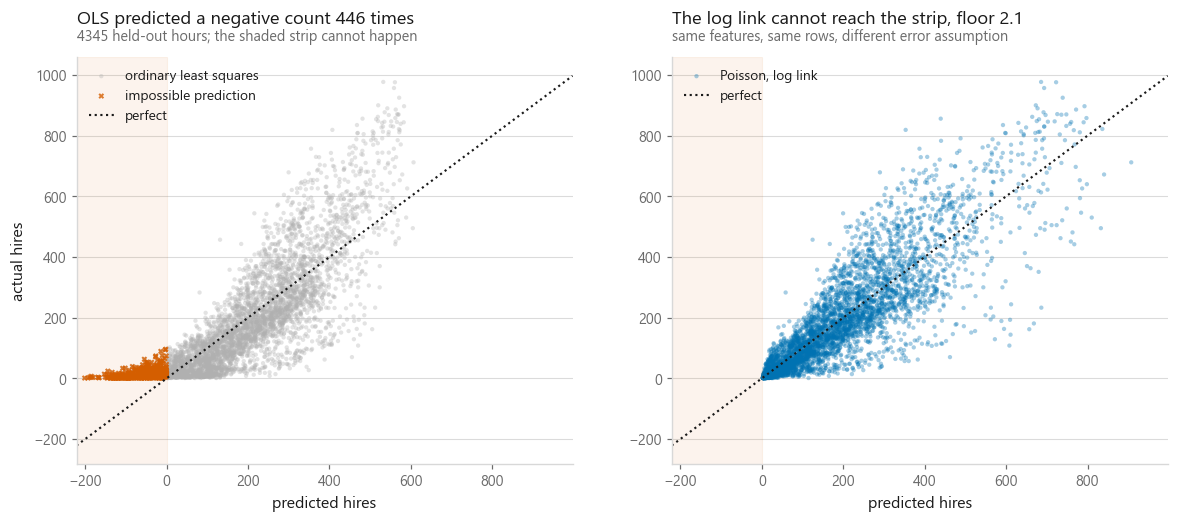

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax = axes[0]
ax.scatter(pred_ols, y_te, s=8, color=style.NEUTRAL, alpha=0.35, edgecolor="none",
           label="ordinary least squares")
ax.scatter(pred_ols[pred_ols < 0], y_te[pred_ols < 0], s=14, color=style.HIGHLIGHT,
           alpha=0.8, edgecolor="none", marker="X", label="impossible prediction")
lim = [min(pred_ols.min(), 0) - 20, max(pred_ols.max(), y_te.max()) + 20]
ax.plot(lim, lim, color=style.INK, ls=":", lw=1.4, label="perfect")
ax.axvspan(lim[0], 0, color=style.HIGHLIGHT, alpha=0.07)
ax.set_xlim(lim)
ax.set_xlabel("predicted hires")
ax.set_ylabel("actual hires")
ax.legend(fontsize=9, loc="upper left")
style.title(ax, f"OLS predicted a negative count {negatives} times",
            f"{len(y_te)} held-out hours; the shaded strip cannot happen")

ax = axes[1]
ax.scatter(pred_poisson, y_te, s=8, color=style.PALETTE[0], alpha=0.35,
           edgecolor="none", label="Poisson, log link")
ax.plot(lim, lim, color=style.INK, ls=":", lw=1.4, label="perfect")
ax.axvspan(lim[0], 0, color=style.HIGHLIGHT, alpha=0.07)
ax.set_xlim(lim)
ax.set_xlabel("predicted hires")
ax.legend(fontsize=9, loc="upper left")
style.title(ax, f"The log link cannot reach the strip, floor {pred_poisson.min():.1f}",
            "same features, same rows, different error assumption")
style.save(fig, FIG / "fig-01-negative-counts.png")

### How the residuals spread

The impossible predictions are the visible failure. The invisible one is the
assumption about spread, and the way to see it is to sort the held-out hours by
what the model itself predicted and measure the residual spread inside each
group.

If least squares were right, that spread would be flat across the groups. If
Poisson were right, the spread divided by the square root of the prediction
would be flat instead, because the Poisson variance is the mean.

In [5]:
GROUPS = 8


def spread_table(pred, actual, groups=GROUPS):
    """Residual spread inside equal-sized groups of the model's own prediction."""
    frame = pd.DataFrame({"pred": pred, "resid": actual - pred})
    frame["bin"] = pd.qcut(frame["pred"], groups, duplicates="drop")
    out = frame.groupby("bin", observed=True).agg(
        rows=("resid", "size"), level=("pred", "mean"), resid_sd=("resid", "std"))
    return out.reset_index(drop=True)


ols_spread = spread_table(pred_ols, y_te)
poisson_spread = spread_table(pred_poisson, y_te)

# Only the Poisson table gets the scaled column. Dividing by the square root of
# an OLS prediction would mean taking the root of a negative number in the lowest
# group, which is exactly the trouble that model is already in.
poisson_spread["sd / sqrt(level)"] = (poisson_spread["resid_sd"]
                                      / np.sqrt(poisson_spread["level"]))

print("ordinary least squares, residual spread by group of its own prediction")
print(ols_spread.to_string(index=False, float_format="{:.2f}".format))
print("\nPoisson, same table plus the column its own assumption calls flat")
print(poisson_spread.to_string(index=False, float_format="{:.2f}".format))

ols_fan = ols_spread["resid_sd"].max() / ols_spread["resid_sd"].min()
poisson_fan = poisson_spread["sd / sqrt(level)"].max() / poisson_spread["sd / sqrt(level)"].min()
overshoot = poisson_spread["sd / sqrt(level)"].min()
print(f"\nOLS assumes flat residual spread; it varies by a factor of {ols_fan:.2f}")
print(f"Poisson assumes flat spread over sqrt(mean); that varies by a factor of "
      f"{poisson_fan:.2f}")
print(f"and it never falls below {overshoot:.2f}, where Poisson would put it at 1.00")

ordinary least squares, residual spread by group of its own prediction
 rows  level  resid_sd
  544 -45.60     43.11
  543  44.75     35.27
  543 102.45     50.78
  543 155.94     68.64
  543 211.42     85.68
  543 267.31    108.85
  543 326.55    134.15
  543 443.43    169.70

Poisson, same table plus the column its own assumption calls flat
 rows  level  resid_sd  sd / sqrt(level)
  544  10.29     10.97              3.42
  543  34.41     28.27              4.82
  543  81.21     39.41              4.37
  543 132.34     62.76              5.46
  543 186.68     83.73              6.13
  543 245.45    105.40              6.73
  543 324.57    126.19              7.00
  543 504.31    162.09              7.22

OLS assumes flat residual spread; it varies by a factor of 4.81
Poisson assumes flat spread over sqrt(mean); that varies by a factor of 2.11
and it never falls below 3.42, where Poisson would put it at 1.00


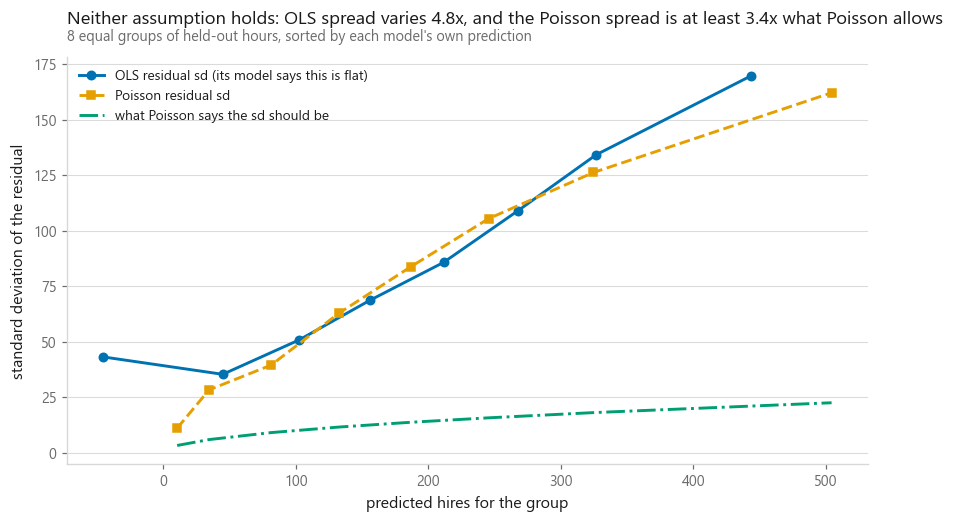

In [6]:
fig, ax = plt.subplots(figsize=(9.4, 4.8))

ax.plot(ols_spread["level"], ols_spread["resid_sd"], color=style.PALETTE[0],
        ls="-", marker=style.MARKERS[0], lw=1.9,
        label="OLS residual sd (its model says this is flat)")
ax.plot(poisson_spread["level"], poisson_spread["resid_sd"], color=style.PALETTE[1],
        ls="--", marker=style.MARKERS[1], lw=1.9, label="Poisson residual sd")
ax.plot(poisson_spread["level"], np.sqrt(poisson_spread["level"]),
        color=style.PALETTE[2], ls="-.", lw=1.9,
        label="what Poisson says the sd should be")
ax.set_xlabel("predicted hires for the group")
ax.set_ylabel("standard deviation of the residual")
ax.legend(fontsize=9, loc="upper left")
style.title(ax,
            f"Neither assumption holds: OLS spread varies {ols_fan:.1f}x, and the "
            f"Poisson spread is at least {overshoot:.1f}x what Poisson allows",
            f"{GROUPS} equal groups of held-out hours, sorted by each model's own prediction")
style.save(fig, FIG / "fig-02-residual-spread.png")

Two failures in one chart, and the second one is the interesting one.

Least squares assumed a flat line and got a rising one. That is the
heteroskedasticity [quantile regression](../08-quantile-regression/) worked
around by refusing to model the mean at all.

The Poisson model expected its residual spread to follow the square root of the
level, and the observed spread is far above that curve everywhere. The Poisson
variance assumption is not slightly off. It is wrong by a lot, in the direction
that makes the model overconfident.

## 5. Testing the Poisson assumption, which is where the notebook turns

The standard test is the Pearson statistic divided by its degrees of freedom.
Each row contributes its squared residual scaled by the variance the model
claims:

$$\hat\phi = \frac{1}{n - p}\sum_i \frac{(y_i - \hat\mu_i)^2}{V(\hat\mu_i)}$$

Under a correct Poisson model this lands near one. Above one is
**overdispersion**: the data varies more than the family allows.

This is the conditional version of the ratio printed in the very first cell.
The unconditional ratio was inflated simply because busy hours and quiet hours
are mixed together. This one has already removed everything the features
explain, so whatever is left over is the family's problem.

In [7]:
import statsmodels.api as sm

A_const = sm.add_constant(A)
B_const = sm.add_constant(B, has_constant="add")

t0 = time.time()
sm_poisson = sm.GLM(y_tr, A_const, family=sm.families.Poisson()).fit()
print(f"statsmodels Poisson fitted in {time.time() - t0:.1f}s")

dispersion = float(sm_poisson.pearson_chi2 / sm_poisson.df_resid)
print(f"\nPearson chi-squared over degrees of freedom : {dispersion:.2f}")
print(f"deviance over degrees of freedom            : {sm_poisson.deviance / sm_poisson.df_resid:.2f}")
print(f"a correct Poisson model puts both near      : 1.00")
print(f"\nunconditional variance-to-mean ratio was    : {y_bike.var() / y_bike.mean():.1f}")
print(f"after the model explains what it can, still : {dispersion:.1f}")

# The variance-to-mean ratio, computed inside groups of similar fitted mean, so
# that the mixing effect is removed by construction rather than by argument.
mu_tr = sm_poisson.fittedvalues
groups = pd.DataFrame({"mu": mu_tr, "y": y_tr})
groups["bin"] = pd.qcut(groups["mu"], 12, duplicates="drop")
vm = groups.groupby("bin", observed=True).agg(
    rows=("y", "size"), mean=("y", "mean"), var=("y", "var")).reset_index(drop=True)
vm["variance / mean"] = vm["var"] / vm["mean"]
print()
print(vm.to_string(index=False, float_format="{:.2f}".format))

statsmodels Poisson fitted in 2.0s

Pearson chi-squared over degrees of freedom : 31.98
deviance over degrees of freedom            : 32.72
a correct Poisson model puts both near      : 1.00

unconditional variance-to-mean ratio was    : 173.7
after the model explains what it can, still : 32.0

 rows   mean      var  variance / mean
 1087   7.98    66.63             8.35
 1086  19.81   340.33            17.18
 1086  38.74   981.14            25.33
 1086  67.88  1433.60            21.12
 1086 101.01  2729.67            27.02
 1086 142.40  4236.99            29.75
 1086 185.31  6844.29            36.93
 1086 223.34  8831.04            39.54
 1086 258.29 11001.06            42.59
 1086 312.75 14719.13            47.06
 1086 381.38 18790.94            49.27
 1087 537.20 35406.63            65.91


log-log slope of variance against mean : 1.425
Poisson would need                     : 1.000
Gamma would need                       : 2.000


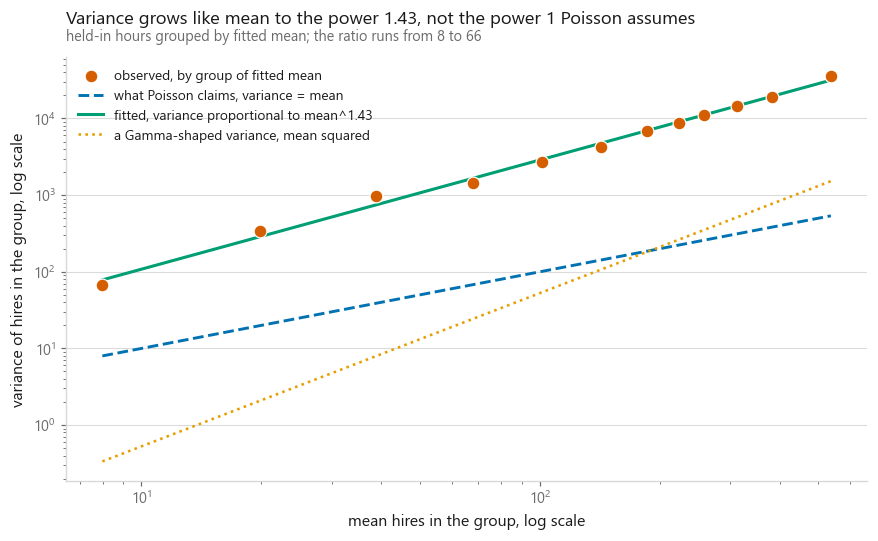

In [8]:
power, log_scale = np.polyfit(np.log(vm["mean"]), np.log(vm["var"]), 1)

fig, ax = plt.subplots(figsize=(9.4, 5.0))

ax.scatter(vm["mean"], vm["var"], s=70, color=style.HIGHLIGHT, zorder=3,
           edgecolor="white", linewidth=0.8, label="observed, by group of fitted mean")
grid = np.linspace(vm["mean"].min(), vm["mean"].max(), 100)
ax.plot(grid, grid, color=style.PALETTE[0], ls="--", lw=1.9,
        label="what Poisson claims, variance = mean")
ax.plot(grid, np.exp(log_scale) * grid ** power, color=style.PALETTE[2], ls="-", lw=2.0,
        label=f"fitted, variance proportional to mean^{power:.2f}")
ax.plot(grid, (grid ** 2) / vm["mean"].mean(), color=style.PALETTE[1], ls=":", lw=1.7,
        label="a Gamma-shaped variance, mean squared")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean hires in the group, log scale")
ax.set_ylabel("variance of hires in the group, log scale")
ax.legend(fontsize=9, loc="upper left")
style.title(ax,
            f"Variance grows like mean to the power {power:.2f}, not the power 1 Poisson assumes",
            f"held-in hours grouped by fitted mean; the ratio runs from "
            f"{vm['variance / mean'].min():.0f} to {vm['variance / mean'].max():.0f}")
style.save(fig, FIG / "fig-03-variance-to-mean.png")

print(f"log-log slope of variance against mean : {power:.3f}")
print(f"Poisson would need                     : 1.000")
print(f"Gamma would need                       : 2.000")

**This is the finding, and it outranks everything about the link function.**

The variance-to-mean ratio is far above one in every group, and it climbs with
the level. The Poisson family is not describing this data. It is not a small
violation to note in a limitations paragraph, because of what it does next.

## The part that actually bites: standard errors

A Poisson GLM's standard errors are computed from the assumption that the
variance equals the mean. If the true variance is many times larger, every
standard error is too small by roughly the square root of that factor, and
every confidence interval is too narrow by the same amount.

There are two standard repairs.

**Quasi-Poisson** keeps the Poisson mean model and multiplies the variance by a
single estimated $\phi$. It changes no coefficient and rescales every standard
error by $\sqrt{\phi}$. It is a correction, not a model, because there is no
distribution with that variance.

**Negative binomial** is a real distribution. It arises as a Poisson whose rate
is itself Gamma-distributed, which is exactly the situation here: hourly demand
has a rate that wobbles for reasons the features do not capture, such as
events, weather that the three weather codes do not resolve, and whatever else
happens in a city. Its variance is $\mu + \alpha\mu^2$, so $\alpha$ is a dial
from Poisson at zero to something much wider.

The dial gets estimated from the data by the auxiliary regression of Cameron
and Trivedi: regress $\frac{(y - \hat\mu)^2 - y}{\hat\mu}$ on $\hat\mu$ through
the origin, and the slope is $\alpha$.

In [9]:
aux_target = ((y_tr - mu_tr) ** 2 - y_tr) / mu_tr
alpha_hat = float(np.linalg.lstsq(np.asarray(mu_tr).reshape(-1, 1), aux_target,
                                  rcond=None)[0][0])

t0 = time.time()
sm_nb = sm.GLM(y_tr, A_const,
               family=sm.families.NegativeBinomial(alpha=alpha_hat)).fit()
sm_quasi = sm.GLM(y_tr, A_const, family=sm.families.Poisson()).fit(scale="X2")
print(f"negative binomial and quasi-Poisson fitted in {time.time() - t0:.1f}s")

print(f"\nestimated alpha                        : {alpha_hat:.4f}")
print(f"Poisson dispersion after the Poisson fit: {dispersion:.2f}")
print(f"Pearson over df after the NB fit        : "
      f"{sm_nb.pearson_chi2 / sm_nb.df_resid:.2f}")
print(f"\nAIC, Poisson : {sm_poisson.aic:,.0f}")
print(f"AIC, negative binomial : {sm_nb.aic:,.0f}")

se = pd.DataFrame({"coefficient": sm_poisson.params,
                   "se Poisson": sm_poisson.bse,
                   "se quasi-Poisson": sm_quasi.bse,
                   "se negative binomial": sm_nb.bse},
                  index=["intercept"] + feature_names)
se["quasi / Poisson"] = se["se quasi-Poisson"] / se["se Poisson"]
se["NB / Poisson"] = se["se negative binomial"] / se["se Poisson"]

print(f"\nmedian standard error inflation, quasi over Poisson : "
      f"{se['quasi / Poisson'].median():.2f}")
print(f"square root of the dispersion                        : {np.sqrt(dispersion):.2f}")
print(f"median standard error inflation, NB over Poisson     : "
      f"{se['NB / Poisson'].median():.2f}")

inside = ((sm_nb.params >= sm_poisson.params - 1.96 * sm_poisson.bse) &
          (sm_nb.params <= sm_poisson.params + 1.96 * sm_poisson.bse))
print(f"\nnegative binomial estimates falling inside the Poisson 95% intervals: "
      f"{int(inside.sum())} of {len(inside)}")
print(f"coefficients called significant at the 5% level: "
      f"Poisson {int((sm_poisson.pvalues < 0.05).sum())}, "
      f"quasi {int((sm_quasi.pvalues < 0.05).sum())}, "
      f"negative binomial {int((sm_nb.pvalues < 0.05).sum())}, "
      f"out of {len(sm_poisson.pvalues)}")

negative binomial and quasi-Poisson fitted in 4.0s

estimated alpha                        : 0.1260
Poisson dispersion after the Poisson fit: 31.98
Pearson over df after the NB fit        : 1.78

AIC, Poisson : 508,123
AIC, negative binomial : 144,914

median standard error inflation, quasi over Poisson : 5.66
square root of the dispersion                        : 5.66
median standard error inflation, NB over Poisson     : 4.14

negative binomial estimates falling inside the Poisson 95% intervals: 11 of 54
coefficients called significant at the 5% level: Poisson 52, quasi 47, negative binomial 50, out of 54


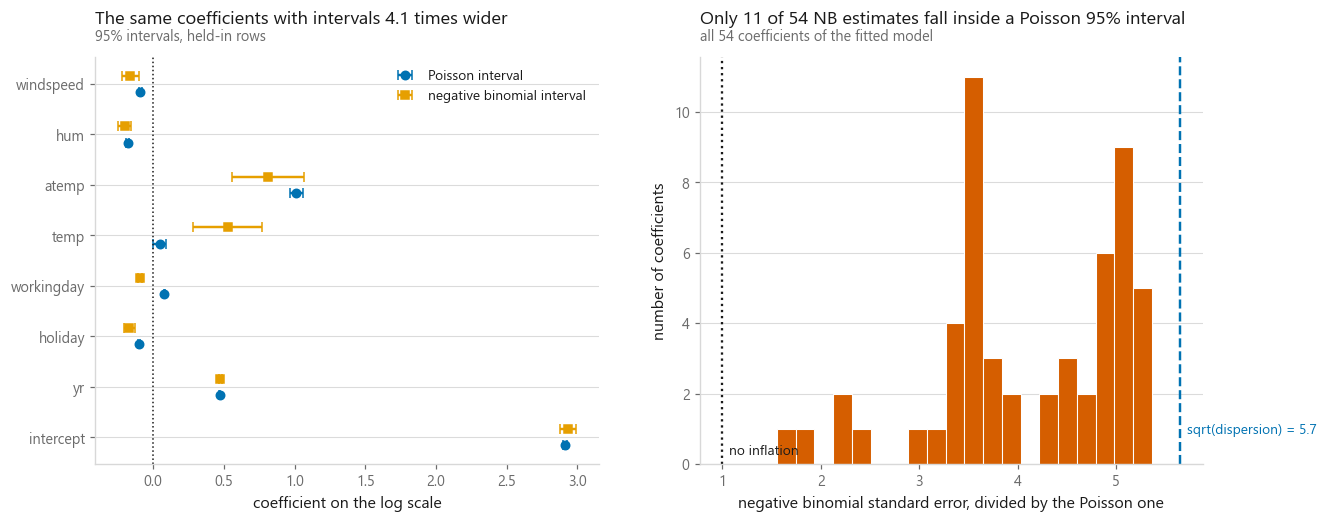

In [10]:
show = ["intercept"] + [n for n in feature_names if n.startswith("num__")]
panel = se.loc[show]
short = [n.replace("num__", "") for n in show]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax = axes[0]
pos = np.arange(len(panel))
ax.errorbar(panel["coefficient"], pos - 0.16, xerr=1.96 * panel["se Poisson"],
            fmt=style.MARKERS[0], color=style.PALETTE[0], capsize=3, lw=1.6,
            label="Poisson interval")
ax.errorbar(sm_nb.params[[se.index.get_loc(n) for n in show]], pos + 0.16,
            xerr=1.96 * panel["se negative binomial"], fmt=style.MARKERS[1],
            color=style.PALETTE[1], capsize=3, lw=1.6, label="negative binomial interval")
ax.axvline(0, color=style.INK, lw=1.0, ls=":")
ax.set_yticks(pos, short)
ax.set_xlabel("coefficient on the log scale")
ax.legend(fontsize=9)
style.title(ax, f"The same coefficients with intervals {se['NB / Poisson'].median():.1f} times wider",
            "95% intervals, held-in rows")

ax = axes[1]
ratios = se["NB / Poisson"].to_numpy()
ax.hist(ratios, bins=20, color=style.HIGHLIGHT, edgecolor="white", linewidth=0.7)
ax.axvline(1.0, color=style.INK, ls=":", lw=1.5)
ax.annotate("no inflation", xy=(1.0, 0), xytext=(4, 6), textcoords="offset points",
            fontsize=9, color=style.INK)
ax.axvline(np.sqrt(dispersion), color=style.PALETTE[0], ls="--", lw=1.6)
ax.annotate(f"sqrt(dispersion) = {np.sqrt(dispersion):.1f}", xy=(np.sqrt(dispersion), 0),
            xytext=(4, 20), textcoords="offset points", fontsize=9, color=style.PALETTE[0])
ax.set_xlabel("negative binomial standard error, divided by the Poisson one")
ax.set_ylabel("number of coefficients")
style.title(ax,
            f"Only {int(inside.sum())} of {len(inside)} NB estimates fall inside a "
            f"Poisson 95% interval",
            f"all {len(ratios)} coefficients of the fitted model")
style.save(fig, FIG / "fig-04-standard-errors.png")

### Reading that honestly

The quasi-Poisson inflation factor comes out at the square root of the
dispersion, exactly, because that is arithmetically what quasi-Poisson does.
Printing it is a check on my own understanding rather than a discovery.

The negative binomial inflation is the one that matters, because it comes from
a fitted distribution rather than a multiplier, and the count of NB estimates
landing inside the Poisson intervals is the number to quote at anybody who
reports a Poisson regression on data they did not test for overdispersion.
Those intervals are not slightly optimistic. They mostly exclude the estimate a
better-specified model produces.

One counter-result, printed above, keeps this from being a tidy story. The
count of coefficients called significant at the five percent level barely
moved. With this many rows the standard errors are small enough that even
inflating them several times leaves most coefficients comfortably distinguished
from zero. So the practical damage is to the intervals, which are what an
analyst should actually be reporting, and not to the stars in a table, which
are what usually gets read.

## The surprise: the better model predicted slightly worse

In [11]:
pred_sm_poisson = sm_poisson.predict(B_const)
pred_sm_nb = sm_nb.predict(B_const)

print(f"{'':>20} {'MAE':>8} {'RMSE':>8}")
for name, pred in [("Poisson GLM", pred_sm_poisson), ("negative binomial", pred_sm_nb)]:
    print(f"{name:>20} {mean_absolute_error(y_te, pred):>8.2f} "
          f"{np.sqrt(((y_te - pred) ** 2).mean()):>8.2f}")
print(f"\nAIC favoured negative binomial by {sm_poisson.aic - sm_nb.aic:,.0f}")
print(f"held-out MAE favoured "
      f"{'negative binomial' if mean_absolute_error(y_te, pred_sm_nb) < mean_absolute_error(y_te, pred_sm_poisson) else 'Poisson'}"
      f" by {abs(mean_absolute_error(y_te, pred_sm_nb) - mean_absolute_error(y_te, pred_sm_poisson)):.2f} hires")

                          MAE     RMSE
         Poisson GLM    61.41    91.43
   negative binomial    63.42    99.99

AIC favoured negative binomial by 363,209
held-out MAE favoured Poisson by 2.02 hires


I expected the negative binomial to win on both counts and it did not. The
likelihood improved enormously and the held-out error moved the other way.

The explanation is in the weights. Both models have the same mean model,
$\mu = e^{x^\top\beta}$, and both estimate it by weighted least squares on a
working response. Poisson weights each row by $\mu$. Negative binomial weights
it by $\mu / (1 + \alpha\mu)$, which flattens out as $\mu$ grows, so the busy
hours count for relatively less. Since the busy hours are also where the
absolute errors are largest, down-weighting them costs mean absolute error.

The deeper reason the Poisson fit survives is a property worth knowing: the
Poisson score equation $X^\top(y - \mu) = 0$ only requires the **mean** model
to be right. Get the variance wrong and the coefficients are still consistent,
only inefficient, and only the standard errors are broken. That is why
quasi-Poisson is such a common recommendation, and why "the family is wrong" is
an inference problem before it is a prediction problem.

## 6. Gamma, Tweedie, and letting the data choose the power

Section 5 measured the exponent linking variance to mean. Poisson assumes one,
Gamma assumes two, and Tweedie takes the exponent as a parameter. So rather
than pick a family from habit, hand the measured exponent to `TweedieRegressor`
and see whether it helps.

In [12]:
from sklearn.linear_model import GammaRegressor, TweedieRegressor

families = [
    ("OLS, no link", LinearRegression()),
    ("Poisson, p = 1", PoissonRegressor(alpha=1e-8, max_iter=1000)),
    (f"Tweedie, p = {power:.2f}", TweedieRegressor(power=float(power), link="log",
                                                   alpha=1e-8, max_iter=1000)),
    ("Tweedie, p = 1.5", TweedieRegressor(power=1.5, link="log", alpha=1e-8,
                                          max_iter=1000)),
    ("Gamma, p = 2", GammaRegressor(alpha=1e-8, max_iter=1000)),
]

rows = []
for name, model in families:
    t0 = time.time()
    model.fit(A, y_tr)
    pred = model.predict(B)
    safe = np.clip(pred, 1e-6, None)
    rows.append({"family": name,
                 "MAE": mean_absolute_error(y_te, pred),
                 "RMSE": float(np.sqrt(((y_te - pred) ** 2).mean())),
                 "Poisson deviance": mean_poisson_deviance(y_te, safe),
                 "lowest prediction": float(pred.min()),
                 "seconds": time.time() - t0})

sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format="{:.3f}".format))

           family    MAE    RMSE  Poisson deviance  lowest prediction  seconds
     OLS, no link 76.373 102.656            90.111           -201.255    0.017
   Poisson, p = 1 61.406  91.426            34.057              2.103    0.200
Tweedie, p = 1.43 61.781  93.302            34.194              2.112    0.176
 Tweedie, p = 1.5 61.915  93.875            34.306              2.080    0.150
     Gamma, p = 2 64.678 104.345            37.622              1.825    0.042


lowest held-out MAE: Poisson, p = 1, at 61.41 hires
the measured exponent was 1.43, so the Tweedie fitted at that power scored 61.78
and the plain Poisson scored 61.41


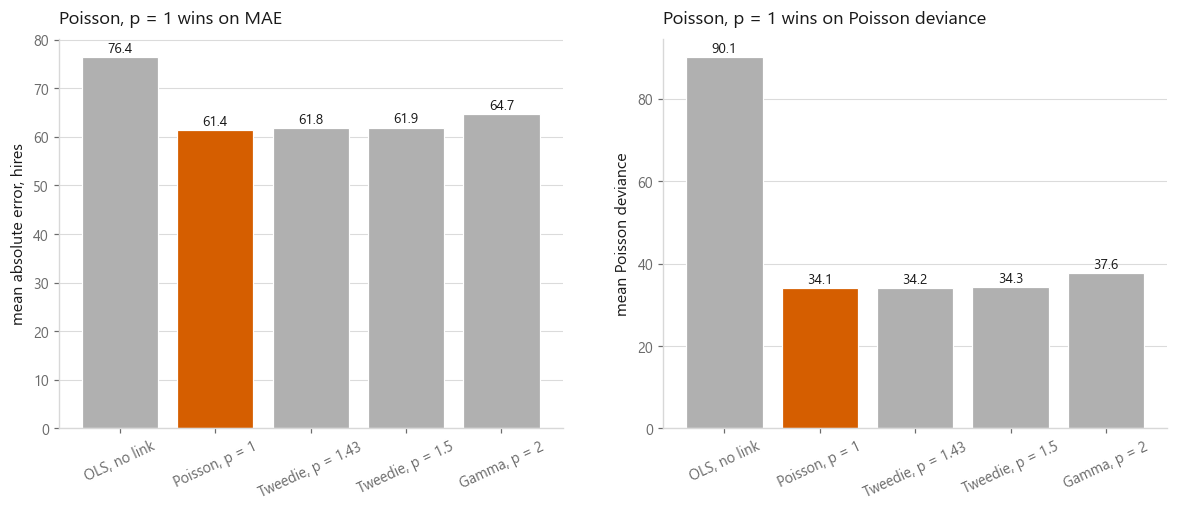

In [13]:
best = sweep.loc[sweep["MAE"].idxmin()]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

for ax, col, label in zip(axes, ["MAE", "Poisson deviance"],
                          ["mean absolute error, hires", "mean Poisson deviance"]):
    winner = int(sweep[col].idxmin())
    ax.bar(sweep["family"], sweep[col], color=style.spot(len(sweep), winner),
           edgecolor="white", linewidth=0.8)
    for i, v in enumerate(sweep[col]):
        ax.annotate(f"{v:.1f}", xy=(i, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=9, color=style.INK)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=25)
    style.title(ax, f"{sweep['family'].iloc[winner]} wins on {col}")

style.save(fig, FIG / "fig-05-families.png")

print(f"lowest held-out MAE: {best['family']}, at {best['MAE']:.2f} hires")
print(f"the measured exponent was {power:.2f}, so the Tweedie fitted at that power "
      f"scored {sweep.loc[sweep['family'].str.startswith('Tweedie, p = ' + f'{power:.2f}'), 'MAE'].iloc[0]:.2f}")
print(f"and the plain Poisson scored "
      f"{sweep.loc[sweep['family'] == 'Poisson, p = 1', 'MAE'].iloc[0]:.2f}")

The measured exponent did not buy a better prediction, which is the second time
in this notebook that the better-specified variance lost on held-out error. The
pattern is the same both times, and it is the useful lesson.

**The variance function is about how much you should believe the fit, not about
where the fit goes.** Choosing it correctly buys honest intervals, honest
standard errors and honest model comparison. It does not move the mean model
much, because the mean model was already consistent without it.

So the decision rule is short. If you are predicting, get the link right, stop
worrying about the family, and measure held-out error. If you are explaining,
get the family right, because everything you are about to report is a standard
error and the Poisson ones on this dataset were several times too small.

## Cheat sheet

| | |
|---|---|
| **Link** | The part that stops impossible predictions. Log link for counts and amounts, logit for probabilities. Choose it from the range of the target |
| **Family** | The part that sets the variance function and therefore the standard errors. Choose it by measuring, not by habit |
| **Poisson** | `PoissonRegressor`, or statsmodels for inference. Assumes variance equals mean. Test that assumption every time |
| **Overdispersion** | Pearson chi-squared over degrees of freedom, above one. Fix with quasi-Poisson for a quick correction or negative binomial for a real distribution |
| **Gamma** | Positive continuous amounts, variance growing with the square of the mean. Claim sizes, durations, spend |
| **Tweedie** | Variance as a free power of the mean, and the only easy option when the target has a spike at exactly zero |
| **Watch out** | The Poisson mean estimate stays consistent under the wrong variance. The standard errors do not. Wrong family is an inference bug, not a prediction bug |
| **Next** | [Logistic regression](../../03-classification/01-logistic-regression/), which is this machinery with a logit link |

## What to remember

1. Bike Sharing counts are overdispersed, and after the model explained
   everything it could the leftover dispersion was still far above the one a
   Poisson model assumes. That is the headline result of this notebook.
2. Test that, do not assume it. The Pearson statistic over degrees of freedom is
   one line and it decides whether your standard errors mean anything.
3. The unconditional variance-to-mean ratio is not the test. Mixing hours of
   different demand inflates it even when every hour is perfectly Poisson.
   Condition on the fitted mean first.
4. Overdispersion inflates standard errors by roughly the square root of the
   dispersion. Most of the negative binomial estimates here fell outside the
   Poisson confidence intervals for the same coefficients.
5. The count of significant coefficients barely changed, because the sample is
   large. Significance stars are the least sensitive thing in the table, which
   is a reason to report intervals instead.
6. The negative binomial fitted far better by AIC and predicted slightly worse
   out of sample. Same mean model, different weights, and the busy hours it
   down-weights are the ones absolute error cares about.
7. A log link is what stops negative predictions, and it did. Least squares put
   a sizeable share of held-out hours below zero, which no loss function or
   outlier treatment would have fixed.
8. Measuring the exponent that links variance to mean is worth doing, and on
   this data it landed between the Poisson and Gamma values. Handing it to
   Tweedie did not improve held-out error, which is the same lesson as point 6.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-01 Logistic regression](../../03-classification/01-logistic-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#GLM` `#PoissonRegression` `#NegativeBinomial` `#Overdispersion`
`#Tweedie` `#StatsModels` `#ScikitLearn` `#Python` `#DataScience`